In [21]:
from google.colab import files
uploaded = files.upload()

Saving balanced_fault_dataset.csv to balanced_fault_dataset (1).csv


Training XGBoost Regressor...

[XGBoost Performance]
R-Squared: 0.9994
MSE: 0.000063


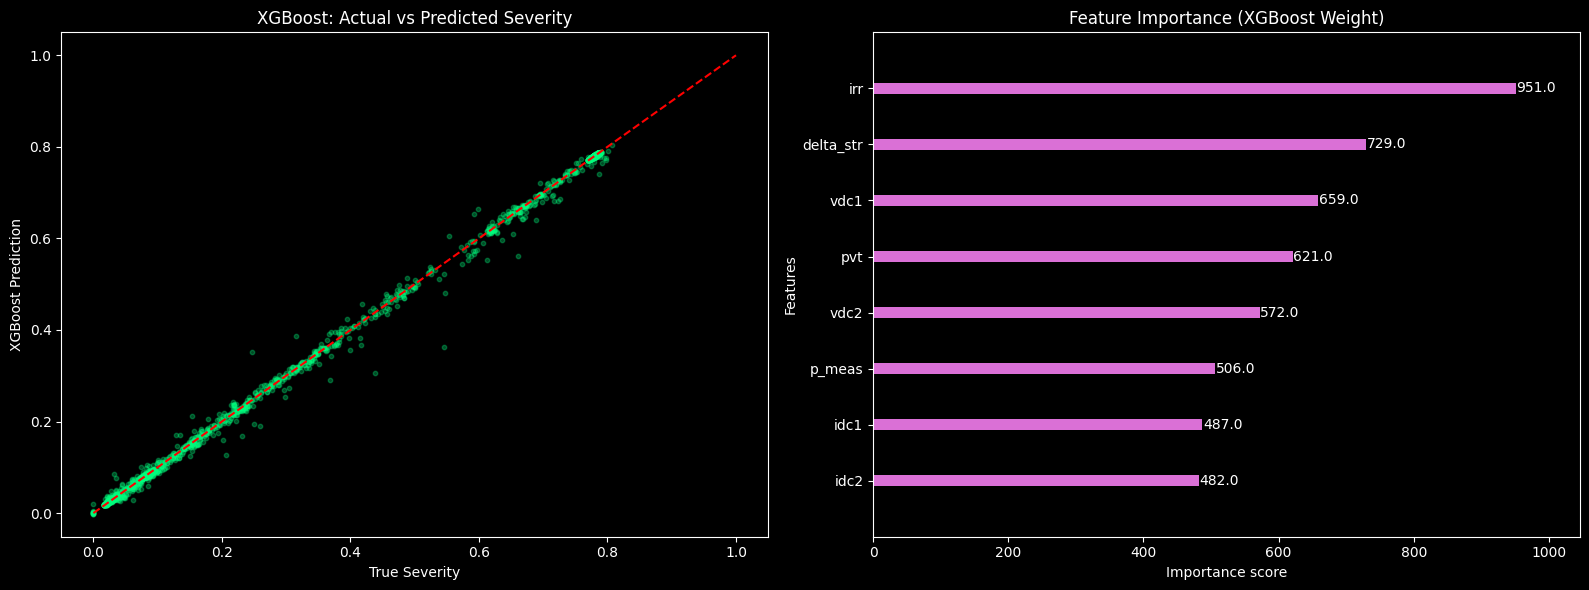

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the balanced fault dataset
df = pd.read_csv('balanced_fault_dataset.csv')

# 2. Define Features and Target
features = ['vdc1', 'vdc2', 'idc1', 'idc2', 'irr', 'pvt', 'p_meas', 'delta_str']
X = df[features]
y = df['severity_index']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train XGBoost Regressor
# Using objective 'reg:squarederror' for numerical prediction
print("Training XGBoost Regressor...")
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 5. Prediction and Confidence Scoring
y_pred = model.predict(X_test)

# For XGBoost, we calculate confidence by measuring the "instability"
# of the prediction across a small subsample of the trees (boosters)
# Standard deviation of the cumulative predictions
# We sample a subset of trees to calculate variance for the confidence score
tree_preds = np.array([model.predict(X_test, iteration_range=(0, i), validate_features=False) for i in range(10, 101, 10)])
std_dev = np.std(tree_preds, axis=0)
confidence = np.clip(100 * (1 - (std_dev / (std_dev.max() + 1e-6))), 0, 100)

# 6. Evaluation
print(f"\n[XGBoost Performance]")
print(f"R-Squared: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 7. Visualization (Dark Theme)
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Prediction Accuracy
ax1.scatter(y_test, y_pred, alpha=0.3, color='springgreen', s=10)
ax1.plot([0, 1], [0, 1], color='red', linestyle='--')
ax1.set_title('XGBoost: Actual vs Predicted Severity')
ax1.set_xlabel('True Severity')
ax1.set_ylabel('XGBoost Prediction')

# Plot 2: Feature Importance
xgb.plot_importance(model, ax=ax2, color='orchid', grid=False)
ax2.set_title('Feature Importance (XGBoost Weight)')

plt.tight_layout()
plt.show()

In [30]:
# Function to test the model with 3 different scenarios
def test_solar_model(vdc1, vdc2, idc1, idc2, irr, pvt):
    # 1. Feature Engineering (Manual version of our training logic)
    p_meas = (vdc1 * idc1) + (vdc2 * idc2)
    delta_str = abs((vdc1 * idc1) - (vdc2 * idc2)) / (p_meas + 1e-6)

    # Arrange features in a 2D array for the model
    input_data = np.array([[vdc1, vdc2, idc1, idc2, irr, pvt, p_meas, delta_str]])

    # 2. Get Numerical Prediction
    severity_pred = model.predict(input_data)[0]

    # 3. Get Confidence Score
    # We run the input through the internal boosters to see how much they agree
    tree_preds = np.array([model.predict(input_data, iteration_range=(0, i)) for i in range(10, 101, 10)])
    std_dev = np.std(tree_preds)
    # Using the same normalization logic as before
    conf_score = np.clip(100 * (1 - (std_dev / 0.05)), 0, 100) # 0.05 is a typical max std_dev

    return severity_pred, conf_score

# --- TEST CASE 1: Likely Soiling (Slight mismatch, high power) ---
sev1, conf1 = test_solar_model(260, 200, 9.2, 9.0, 990, 43)

# --- TEST CASE 2: Likely String Fault (One string drops to near zero) ---
sev2, conf2 = test_solar_model(260, 50, 9.2, 0.1, 990, 45)

# --- TEST CASE 3: Likely Hardware Failure (Low current despite high sun) ---
sev3, conf3 = test_solar_model(280, 280, 2.5, 2.1, 900, 32)

# Print Results
print("--- MODEL TEST RESULTS ---")
print(f"Scenario 1 (Soiling):  Severity {sev1:.3f} | Confidence {conf1:.1f}%")
print(f"Scenario 2 (Str Fault): Severity {sev2:.3f} | Confidence {conf2:.1f}%")
print(f"Scenario 3 (Hardware):  Severity {sev3:.3f} | Confidence {conf3:.1f}%")

--- MODEL TEST RESULTS ---
Scenario 1 (Soiling):  Severity 0.094 | Confidence 46.2%
Scenario 2 (Str Fault): Severity 0.797 | Confidence 4.8%
Scenario 3 (Hardware):  Severity 0.271 | Confidence 67.3%
